In [1]:
import tensorflow
from tensorflow import keras
from keras import layers

I0000 00:00:1788165613.216419    1231 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788165614.907286    1231 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788165669.316806    1231 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("RTX 5050 GPU is ready for training!")

TensorFlow Version: 2.21.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
RTX 5050 GPU is ready for training!


W0000 00:00:1788165753.969006    1231 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [3]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU Ready: {gpus}")
    except RuntimeError as e:
        print(e)


GPU Ready: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from tensorflow.keras.layers import Dense,Flatten
from keras import Sequential
from keras.applications.vgg16 import VGG16

In [5]:
model = Sequential()

In [6]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

W0000 00:00:1788165769.291515    1231 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1788165769.505373    1231 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5262 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [7]:
model = Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [8]:
# Split the Dog/Cat folders into train and test sets
path = "/mnt/d/Datasets/PetImages"

img_size = (150, 150)
batch_size = 32

train_ds, test_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    labels="inferred",
    label_mode="binary",
    class_names=["Cat", "Dog"],
    color_mode="rgb",
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="both",
    seed=42,
    shuffle=True,
)

print(train_ds)
print(test_ds)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Using 4998 files for validation.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>


In [9]:
def process(image,label):
    image = tensorflow.cast(image/255.0,tensorflow.float32)
    return image,label
train_ds= train_ds.map(process)
test_ds = test_ds.map(process)

In [10]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model = Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [12]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
conv_base.trainable = False

In [14]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [16]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)

if gpus:
    # Enable dynamic memory growth
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Successfully connected to: {gpus[0].name}")

TensorFlow Version: 2.21.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Successfully connected to: /physical_device:GPU:0


In [17]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
history  = model.fit(train_ds,+ =10,validation_data=test_ds)

Epoch 1/10


/mnt/d/DL-Algorithm/lvenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788150275.235238  179673 service.cc:153] XLA service 0x796114045c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788150275.235285  179673 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788150275.424180  179673 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788150275.893592  179673 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1788150275.926509  179673 dot_merger.cc:481

  3/625 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.4479 - loss: 1.9922 

I0000 00:00:1788150286.225892  179673 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 44/625 ━━━━━━━━━━━━━━━━━━━━ 36s 63ms/step - accuracy: 0.7749 - loss: 0.5639

...

Corrupt JPEG data: 99 extraneous bytes before marker 0xd9


513/625 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.9907 - loss: 0.0279

624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9900 - loss: 0.0291

Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 82ms/step - accuracy: 0.9899 - loss: 0.0292 - val_accuracy: 0.9168 - val_loss: 0.3413


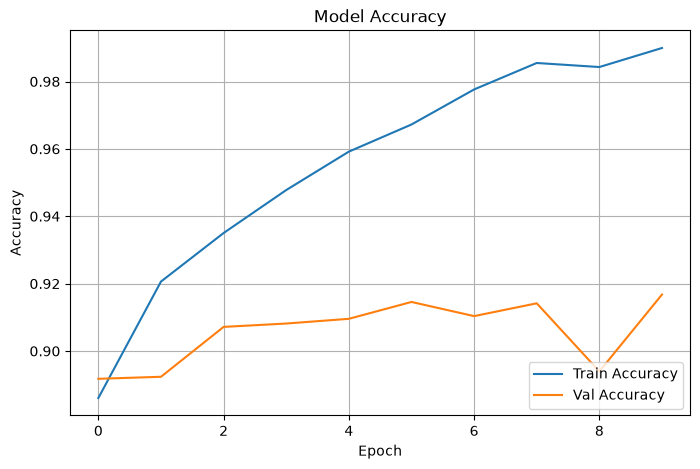

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Now we will try to add some DataArgumentation in it and see how the prediction is increasing

In [27]:
from tensorflow.keras.layers import RandomBrightness,RandomRotation,RandomCrop,RandomZoom

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, RandomBrightness, RandomRotation, RandomZoom
from tensorflow.keras.layers import Flatten, Dense

model2 = Sequential()

model2.add(Input(shape=(150, 150, 3)))

model2.add(RandomBrightness(0.2))
model2.add(RandomRotation(0.2))
model2.add(RandomZoom(0.14))

model2.add(conv_base)

model2.add(Flatten())

model2.add(Dense(256, activation='relu'))

model2.add(Dense(1, activation='sigmoid'))

In [16]:
model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [17]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15
)

Epoch 1/15


/mnt/d/DL-Algorithm/lvenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788165817.707227    1805 service.cc:153] XLA service 0x7bbee0035cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788165817.707288    1805 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788165817.898846    1805 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788165818.475407    1805 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1788165818.529440    1805 dot_merger.cc:481

  3/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.4792 - loss: 1.7289 

I0000 00:00:1788165831.002042    1805 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 44/625 ━━━━━━━━━━━━━━━━━━━━ 38s 66ms/step - accuracy: 0.7720 - loss: 0.5786

...

Corrupt JPEG data: 99 extraneous bytes before marker 0xd9


510/625 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.9939 - loss: 0.0179

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9939 - loss: 0.0178

Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.9939 - loss: 0.0178 - val_accuracy: 0.9106 - val_loss: 0.4578


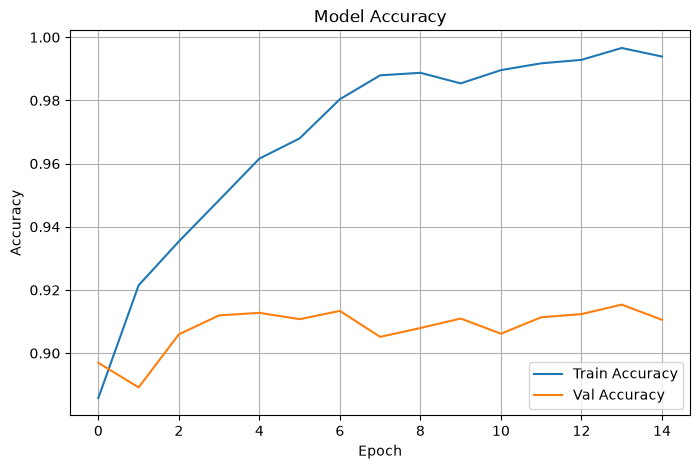

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [19]:
test_ds = tensorflow.keras.utils.image_dataset_from_directory(
    "/mnt/d/Datasets/test",
    labels=None,
    shuffle=False,
    image_size=(150, 150),
    batch_size=32
)

Found 12500 files.


array([[1.        ],
       [0.9999361 ],
       [0.06018078],
       ...,
       [1.        ],
       [0.99999964],
       [0.9999833 ]], shape=(12500, 1), dtype=float32)

In [20]:
response=model2.predict(test_ds)

391/391 ━━━━━━━━━━━━━━━━━━━━ 37s 86ms/step


In [31]:
import pandas as pd

df = pd.DataFrame(response, columns=["label"])
df.index = df.index + 1   # shift index to start from 1
df.to_csv("predictions.csv", index=True, index_label="id")

In [21]:
print(response)

[[1.        ]
 [0.9999361 ]
 [0.06018078]
 ...
 [1.        ]
 [0.99999964]
 [0.9999833 ]]


In [48]:
print(model2.layers[0])
print(model2.layers[0].input_shape)

<RandomBrightness name=random_brightness_2, built=True>


AttributeError: 'RandomBrightness' object has no attribute 'input_shape'

In [49]:
print(model2.layers[0])

<RandomBrightness name=random_brightness_2, built=True>


In [50]:
for i, layer in enumerate(model2.layers):
    print(i, layer.name, type(layer).__name__)

0 random_brightness_2 RandomBrightness
1 random_rotation_2 RandomRotation
2 random_zoom_1 RandomZoom
3 vgg16 Functional
4 flatten_3 Flatten
5 dense_6 Dense
6 dense_7 Dense


In [51]:
print(model2.layers[3].input_shape)

(None, 150, 150, 3)


In [52]:
print(test_ds.element_spec)

TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None)


In [53]:
print(model2.built)

False
